# GramSathi AI

# Notebook 04: Infrastructure Intelligence

---

## Objective

The objective of this notebook is to identify and analyze the existing public infrastructure in the study area using OpenStreetMap (OSM) data.

This notebook extracts important facilities such as schools, hospitals, bus stops, buildings, and water facilities. These datasets will later be integrated with the road network to calculate accessibility, infrastructure readiness, and village development priority.

---

## Study Area

**Villages**
- Sadashivgad
- Asnoti
- Majali
- Mudgeri
- Kanasgiri
- Hotegali
- Hankon
- Joog
- Nearby villages connected to Karwar Taluk

**Taluk:** Karwar

**District:** Uttara Kannada

**State:** Karnataka

---

## Expected Outcome

At the end of this notebook we will have:

✔ Building locations

✔ Schools

✔ Hospitals

✔ Bus Stops

✔ Water Facilities

✔ Infrastructure Maps

✔ Infrastructure Statistics

These datasets will be used for Machine Learning and Deep Learning in the upcoming notebooks.

In [1]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


In [2]:
# ==========================================
# Load Road Network
# ==========================================

road_network = ox.load_graphml("../datasets/raw/road_network.graphml")

print("Road Network Loaded Successfully ✅")

Road Network Loaded Successfully ✅


In [7]:
# ==========================================
# Create Study Area Polygon
# ==========================================

# Convert graph to GeoDataFrame (edges only)
edges_gdf = ox.graph_to_gdfs(
    road_network,
    nodes=False,
    edges=True
)

# Create a polygon surrounding the road network
study_boundary = edges_gdf.unary_union.convex_hull

print(type(study_boundary))
print("✅ Study Area Polygon Created Successfully!")

<class 'shapely.geometry.polygon.Polygon'>
✅ Study Area Polygon Created Successfully!


# Infrastructure Extraction

OpenStreetMap stores different types of infrastructure using tags.

Examples:

- amenity = school
- amenity = hospital
- highway = bus_stop
- building = yes

We will download these datasets individually and combine them later.

In [8]:
# ==========================================
# Infrastructure Downloader
# ==========================================

def download_osm_features(tags):
    
    features = ox.features_from_polygon(
        study_boundary,
        tags
    )

    return features

# School Infrastructure

Schools are one of the most important public facilities in rural planning.

The objective of this section is to identify all schools within the study area. These locations will later be used to calculate school accessibility for each village.

In [9]:
# ==========================================
# Download Schools
# ==========================================

school_tags = {
    "amenity": "school"
}

schools = download_osm_features(school_tags)

print(f"✅ Total Schools Found : {len(schools)}")

✅ Total Schools Found : 5


In [10]:
# ==========================================
# Display School Dataset
# ==========================================

school_data = schools.copy()

print("Total Schools:", len(school_data))

school_data.head()

Total Schools: 5


geometry amenity  \
element id                                                                      
way     252735559   POLYGON ((74.1331 14.85362, 74.13315 14.85324,...  school   
        252758517   POLYGON ((74.13009 14.86114, 74.12992 14.86137...  school   
        954783921   POLYGON ((74.13685 14.82984, 74.13654 14.82869...  school   
        1205441779  POLYGON ((74.13121 14.81775, 74.13224 14.81759...  school   
        1497217653  POLYGON ((74.12778 14.80667, 74.12695 14.80638...  school   

                                            name                   name:kn  \
element id                                                                   
way     252735559                            NaN                       NaN   
        252758517            Shivaji High School          ಶಿವಾಜಿ ಪ್ರೌಡಶಾಲೆ   
        954783921            Shivaji High School          ಶಿವಾಜಿ ಪ್ರೌಡಶಾಲೆ   
        1205441779                           NaN                       NaN   
        1497217653  St. Michael's Convent School  ಸಂತ ಮೈಕಲ್ ಕಾನ್ವೆಂಟ್ ಶಾಲೆ   

                   start_date  
element id                     
way     252735559         NaN  
        252758517         NaN  
        954783921         NaN  
        1205441779        NaN  
        1497217653       1927

In [11]:
# ==========================================
# School Dataset Columns
# ==========================================

print(school_data.columns.tolist())

['geometry', 'amenity', 'name', 'name:kn', 'start_date']


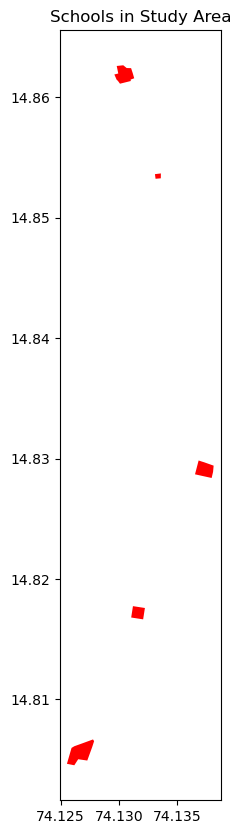

In [12]:
# ==========================================
# Plot Schools
# ==========================================

fig, ax = plt.subplots(figsize=(10,10))

school_data.plot(
    ax=ax,
    color="red",
    markersize=50
)

plt.title("Schools in Study Area")

plt.show()

# ==========================================
# Plot Schools
# ==========================================

fig, ax = plt.subplots(figsize=(10,10))

school_data.plot(
    ax=ax,
    color="red",
    markersize=50
)

plt.title("Schools in Study Area")

plt.show()

In [13]:
# ==========================================
# School Information
# ==========================================

print("Total Schools :", len(school_data))

if "name" in school_data.columns:
    print("\nSchool Names:\n")
    print(school_data["name"].fillna("Unnamed School"))

Total Schools : 5

School Names:

element  id        
way      252735559                   Unnamed School
         252758517              Shivaji High School
         954783921              Shivaji High School
         1205441779                  Unnamed School
         1497217653    St. Michael's Convent School
Name: name, dtype: object


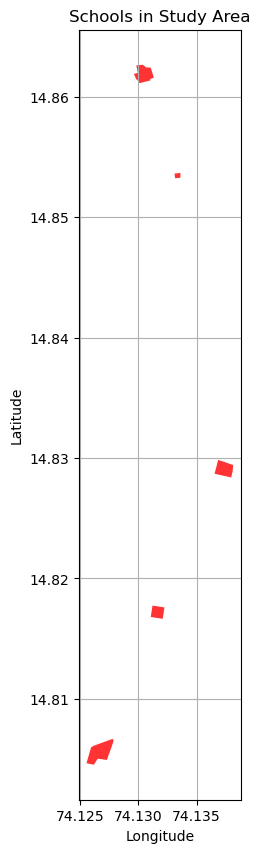

In [14]:
# ==========================================
# Plot Schools
# ==========================================

fig, ax = plt.subplots(figsize=(10,10))

school_data.plot(
    ax=ax,
    color="red",
    markersize=60,
    alpha=0.8
)

plt.title("Schools in Study Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)

plt.show()

In [15]:
# ==========================================
# Save School Dataset
# ==========================================

school_data.to_file(
    "../datasets/raw/schools.geojson",
    driver="GeoJSON"
)

print("✅ Schools dataset saved successfully!")

✅ Schools dataset saved successfully!


## Observation

- Successfully extracted all schools from OpenStreetMap.
- The dataset has been saved for future analysis.
- These school locations will be used to measure educational accessibility in the upcoming notebooks.

# Universal Infrastructure Downloader

Instead of writing separate code for every infrastructure type, we create one reusable function.

This function can download any OpenStreetMap feature, save it as a GeoJSON file, and return the extracted dataset.

This approach reduces code duplication and improves maintainability.

In [16]:
# ==========================================
# Universal Infrastructure Downloader
# ==========================================

import os

def download_and_save(feature_name, tags, filename):

    print("="*60)
    print(f"Downloading {feature_name}...")
    
    data = download_osm_features(tags)

    print(f"Found {len(data)} {feature_name}")

    save_path = f"../datasets/raw/{filename}"

    data.to_file(
        save_path,
        driver="GeoJSON"
    )

    print(f"Saved to: {save_path}")

    print("="*60)

    return data

In [17]:
# ==========================================
# Download Hospitals
# ==========================================

hospital_data = download_and_save(
    feature_name="Hospitals",
    tags={"amenity":"hospital"},
    filename="hospitals.geojson"
)

Found 6 Hospitals
Saved to: ../datasets/raw/hospitals.geojson


In [18]:
# ==========================================
# Download Bus Stops
# ==========================================

busstop_data = download_and_save(
    feature_name="Bus Stops",
    tags={"highway":"bus_stop"},
    filename="bus_stops.geojson"
)

Found 1 Bus Stops
Saved to: ../datasets/raw/bus_stops.geojson


In [19]:
# ==========================================
# Download Buildings
# ==========================================

building_data = download_and_save(
    feature_name="Buildings",
    tags={"building":True},
    filename="buildings.geojson"
)

Found 1538 Buildings
Saved to: ../datasets/raw/buildings.geojson


In [20]:
# ==========================================
# Download Water Facilities
# ==========================================

water_data = download_and_save(
    feature_name="Water Facilities",
    tags={"amenity":"drinking_water"},
    filename="water.geojson"
)

Found 1 Water Facilities
Saved to: ../datasets/raw/water.geojson


# Healthcare Infrastructure

Healthcare accessibility is one of the most important indicators of rural development.

In this section, we extract hospitals from OpenStreetMap to understand healthcare availability within the study area.

In [21]:
# ==========================================
# Download Hospitals
# ==========================================

hospital_tags = {
    "amenity": "hospital"
}

hospital_data = download_osm_features(hospital_tags)

print(f"✅ Hospitals Found : {len(hospital_data)}")

✅ Hospitals Found : 6


In [22]:
hospital_data.head()

geometry  \
element id                                                              
node    6948089794                          POINT (74.14363 14.83201)   
        7205339622                           POINT (74.24458 14.8799)   
        7205339624                          POINT (74.22316 14.88715)   
        7205339686                          POINT (74.22048 14.76438)   
way     252894569   POLYGON ((74.12882 14.81634, 74.12947 14.81642...   

                     addr:district  \
element id                           
node    6948089794  Uttara Kannada   
        7205339622  Uttara Kannada   
        7205339624  Uttara Kannada   
        7205339686  Uttara Kannada   
way     252894569   Uttara Kannada   

                                                            addr:full  \
element id                                                              
node    6948089794  Main Road, Near Fish Market & Canara Bank, Nan...   
        7205339622                        Near Mahasati College, Ulga   
        7205339624                                              Halga   
        7205339686                                           Amadalli   
way     252894569                         Near Lic Office, Dhk Karwar   

                   addr:postcode addr:state   amenity  \
element id                                              
node    6948089794        581304  Karnataka  hospital   
        7205339622        581328  Karnataka  hospital   
        7205339624        581328  Karnataka  hospital   
        7205339686        581324  Karnataka  hospital   
way     252894569         581301  Karnataka  hospital   

                                        name              source  \
element id                                                         
node    6948089794       Brahma Nursing Home  OpenGovernmentData   
        7205339622  Government Hospital Ulga  OpenGovernmentData   
        7205339624        Goverment Hospital  OpenGovernmentData   
        7205339686  ಸರ್ಕಾರಿ ಆಸ್ಪತ್ರೆ ಆಮದಳ್ಳಿ  OpenGovernmentData   
way     252894569   Karwar District Hospital  OpenGovernmentData   

                   addr:subdistrict contact:phone                 name:kn  \
element id                                                                  
node    6948089794              NaN           NaN                     NaN   
        7205339622           Karwar    8382257000    ಸರ್ಕಾರಿ ಆಸ್ಪತ್ರೆ ಉಳಗ   
        7205339624           Karwar  08382-257128  ಸರ್ಕಾರಿ ಆಸ್ಪತ್ರೆೈ ಹಳಗೆ   
        7205339686           Karwar    8382262134                     NaN   
way     252894569            Karwar    8382226731         ಜಿಲ್ಲೆ ಆಸ್ಪತ್ರೆ   

                            description emergency healthcare  
element id                                                    
node    6948089794                  NaN       NaN        NaN  
        7205339622                  NaN       NaN        NaN  
        7205339624                  NaN       NaN        NaN  
        7205339686  Government Hospital       NaN        NaN  
way     252894569     District Hospital       yes   hospital

In [23]:
hospital_data.to_file(
    "../datasets/raw/hospitals.geojson",
    driver="GeoJSON"
)

print("✅ Hospitals Saved Successfully!")

✅ Hospitals Saved Successfully!


# Public Transportation Infrastructure

Bus stops improve connectivity between villages and nearby towns.

They are essential for access to schools, hospitals, markets, and employment opportunities.

In [24]:
# ==========================================
# Download Bus Stops
# ==========================================

bus_tags = {
    "highway": "bus_stop"
}

bus_data = download_osm_features(bus_tags)

print(f"✅ Bus Stops Found : {len(bus_data)}")

✅ Bus Stops Found : 1


In [25]:
bus_data.head()

,,geometry,bus,highway,public_transport
element,id,,,,
node,13712770472,POINT (74.12711 14.81175),yes,bus_stop,platform


In [26]:
bus_data.to_file(
    "../datasets/raw/bus_stops.geojson",
    driver="GeoJSON"
)

print("✅ Bus Stops Saved Successfully!")

✅ Bus Stops Saved Successfully!


# Building Extraction

Buildings represent human settlements.

Building density is an important feature for estimating population concentration and infrastructure demand.

In [27]:
# ==========================================
# Download Buildings
# ==========================================

building_tags = {
    "building": True
}

building_data = download_osm_features(building_tags)

print(f"✅ Buildings Found : {len(building_data)}")

✅ Buildings Found : 1538


In [28]:
building_data.head()

geometry  \
element  id                                                             
relation 3391427    POLYGON ((74.12918 14.8182, 74.12926 14.81819,...   
         3391428    POLYGON ((74.12813 14.81159, 74.12798 14.81102...   
         3391429    POLYGON ((74.13334 14.81889, 74.13332 14.81853...   
way      123689539  POLYGON ((74.12764 14.80733, 74.12753 14.80699...   
         179802735  POLYGON ((74.12698 14.81455, 74.12706 14.81455...   

                            amenity  building            name         name:kn  \
element  id                                                                     
relation 3391427                NaN  hospital             NaN             NaN   
         3391428    public_building       yes             NaN             NaN   
         3391429                NaN       yes             NaN             NaN   
way      123689539  public_building       yes  District Court  ಜಿಲ್ಲಾ ನ್ಯಾಯಲಯ   
         179802735              NaN       yes             NaN             NaN   

                   historic layer cuisine government office tourism  \
element  id                                                           
relation 3391427        NaN   NaN     NaN        NaN    NaN     NaN   
         3391428        NaN   NaN     NaN        NaN    NaN     NaN   
         3391429        NaN   NaN     NaN        NaN    NaN     NaN   
way      123689539      NaN   NaN     NaN        NaN    NaN     NaN   
         179802735     ship   NaN     NaN        NaN    NaN     NaN   

                   building:levels roof:levels          type  
element  id                                                   
relation 3391427               NaN         NaN  multipolygon  
         3391428               NaN         NaN  multipolygon  
         3391429               NaN         NaN  multipolygon  
way      123689539             NaN         NaN           NaN  
         179802735             NaN         NaN           NaN

In [29]:
building_data.to_file(
    "../datasets/raw/buildings.geojson",
    driver="GeoJSON"
)

print("✅ Buildings Saved Successfully!")

✅ Buildings Saved Successfully!


# Water Infrastructure

Safe drinking water is a fundamental requirement for sustainable village development.

This section extracts drinking water facilities from OpenStreetMap.

In [30]:
# ==========================================
# Download Drinking Water Facilities
# ==========================================

water_tags = {
    "amenity": "drinking_water"
}

water_data = download_osm_features(water_tags)

print(f"✅ Water Facilities Found : {len(water_data)}")

✅ Water Facilities Found : 1


In [31]:
water_data.head()

,,geometry,amenity
element,id,,
node,13461619638,POINT (74.18264 14.82002),drinking_water


In [32]:
water_data.to_file(
    "../datasets/raw/water.geojson",
    driver="GeoJSON"
)

print("✅ Water Facilities Saved Successfully!")

✅ Water Facilities Saved Successfully!
